 U-Net + optimización de hiperparámetros + visualización



## 1. Imports y métricas/pérdidas
Reusa las que ya tenías (`dice_coef`, `iou_coef`, `bce_dice_loss`). Si ya las ejecutaste, puedes saltar esta celda.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, Conv2DTranspose,
    MaxPooling2D, UpSampling2D, concatenate, BatchNormalization,
    Activation, Dropout, ZeroPadding2D, Cropping2D)
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
import heapq
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.0 MB/s eta 0:00:00


In [2]:
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(grid, start, goal):

    rows, cols = grid.shape

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}

    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}

    while open_set:

        current = heapq.heappop(open_set)[1]

        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)

            return path[::-1]

        neighbors = [
            (current[0]+1, current[1]),
            (current[0]-1, current[1]),
            (current[0], current[1]+1),
            (current[0], current[1]-1)
        ]

        for neighbor in neighbors:

            r, c = neighbor

            if r < 0 or r >= rows:
                continue

            if c < 0 or c >= cols:
                continue

            if grid[r, c] == 1:
                continue

            tentative_g = g_score[current] + 1

            if neighbor not in g_score or tentative_g < g_score[neighbor]:

                came_from[neighbor] = current
                g_score[neighbor] = tentative_g

                f_score[neighbor] = (
                    tentative_g +
                    heuristic(neighbor, goal)
                )

                heapq.heappush(
                    open_set,
                    (f_score[neighbor], neighbor)
                )

    return None

In [3]:
mapa = np.random.choice(
    [0,1],
    size=(20,20),
    p=[0.8,0.2]
)

inicio = (2,3)
meta = (17,15)

path = astar(mapa, inicio, meta)

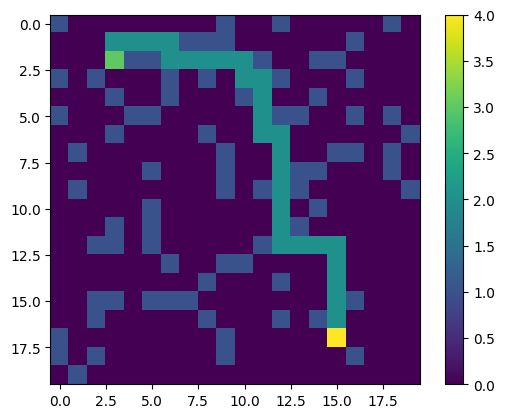

In [4]:
vis = mapa.copy()

if path is not None:
    for p in path:
        vis[p] = 2

vis[inicio] = 3
vis[meta] = 4

plt.imshow(vis)
plt.colorbar()
plt.show()

In [5]:
def generar_mapa(filas=20, columnas=20, prob_obstaculo=0.2):

    mapa = np.random.choice(
        [0, 1],
        size=(filas, columnas),
        p=[1-prob_obstaculo, prob_obstaculo]
    )

    return mapa

def punto_libre(mapa):

    while True:

        x = np.random.randint(0, mapa.shape[0])
        y = np.random.randint(0, mapa.shape[1])

        if mapa[x,y] == 0:
            return (x,y)

def guardar(id_muestra, mapa, inicio, meta, path):

    path_mask = path_to_mask(path, mapa.shape)

    np.savez(
        f"dataset/sample_{id_muestra:05d}.npz",
        mapa=mapa,
        inicio=np.array(inicio),
        meta=np.array(meta),
        path_mask=path_mask
    )

def resample_path(path, target_len):

    path = np.asarray(path, dtype=float)

    if len(path) < 2:
        return np.repeat(path, target_len, axis=0)

    dist = np.sqrt(
        np.sum(np.diff(path, axis=0)**2, axis=1)
    )

    dist = np.insert(np.cumsum(dist), 0, 0)

    total_dist = dist[-1]

    dist_new = np.linspace(
        0,
        total_dist,
        target_len
    )

    fx = interp1d(dist, path[:,0])
    fy = interp1d(dist, path[:,1])

    x_new = fx(dist_new)
    y_new = fy(dist_new)

    return np.column_stack((x_new, y_new))

def path_to_mask(path, shape=(20,20)):

    mask = np.zeros(shape, dtype=np.float32)

    for p in path:

        x = int(round(p[0]))
        y = int(round(p[1]))

        if 0 <= x < shape[0] and 0 <= y < shape[1]:
            mask[x,y] = 1.0

    return mask

In [6]:
if not os.path.exists("dataset"):
    os.makedirs("dataset")
TARGET_LEN = 40

for i in range(5000):

    mapa = generar_mapa()

    inicio = punto_libre(mapa)
    meta = punto_libre(mapa)

    path = astar(mapa, inicio, meta)

    if path is not None:

        path = resample_path(path, TARGET_LEN)

        guardar(i, mapa, inicio, meta, path )

In [7]:
DATASET_DIR = "dataset"

X = []
Y = []

for archivo in os.listdir(DATASET_DIR):

    if not archivo.endswith(".npz"):
        continue

    data = np.load(
        os.path.join(DATASET_DIR, archivo)
    )

    mapa = data["mapa"]
    inicio = data["inicio"]
    meta = data["meta"]
    path_mask = data["path_mask"]

    obstacle_channel = mapa.astype(np.float32)

    start_channel = np.zeros_like(
        obstacle_channel,
        dtype=np.float32
    )

    goal_channel = np.zeros_like(
        obstacle_channel,
        dtype=np.float32
    )

    start_channel[
        inicio[0],
        inicio[1]
    ] = 1.0

    goal_channel[
        meta[0],
        meta[1]
    ] = 1.0

    entrada = np.stack(
        [
            obstacle_channel,
            start_channel,
            goal_channel
        ],
        axis=-1
    )

    X.append(entrada)
    Y.append(path_mask[..., np.newaxis])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print(X.shape)
print(Y.shape)

(4925, 20, 20, 3)
(4925, 20, 20, 1)


In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3940, 20, 20, 3)
(985, 20, 20, 3)


In [9]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


## 2. U-Net parametrizable

Una U-Net  tiene varios niveles de encoder/decoder. El problema con un mapa de **20×20** es que 20 no es divisible muchas veces entre 2, así que **rellenamos (padding)** la entrada hasta el múltiplo de `2**depth` más cercano y al final **recortamos (crop)** de vuelta a 20×20. Esto permite que `depth` sea un hiperparámetro real.

Hiperparámetros expuestos:
- `depth`: número de niveles (2, 3, 4...)
- `base_filters`: filtros del primer nivel (se duplican al bajar)
- `dropout`: regularización en el cuello de botella
- `use_batchnorm`: estabiliza el entrenamiento
- `use_transpose`: `Conv2DTranspose` (aprendible) vs `UpSampling2D` (interpolación)


In [10]:
def conv_block(x, filters, use_batchnorm=True):
    """Doble convolución 3x3 (estilo U-Net clásica)."""
    for _ in range(2):
        x = Conv2D(filters, 3, padding="same",
                   kernel_initializer="he_normal")(x)
        if use_batchnorm:
            x = BatchNormalization()(x)
        x = Activation("relu")(x)
    return x

def build_unet(input_shape=(20, 20, 3),
               depth=3,
               base_filters=32,
               dropout=0.1,
               use_batchnorm=True,
               use_transpose=True):

    inputs = Input(input_shape)

    # --- Padding para que el lado sea divisible entre 2**depth ---
    factor = 2 ** depth
    H = input_shape[0]
    target = int(np.ceil(H / factor) * factor)
    pad = target - H
    x = ZeroPadding2D(((0, pad), (0, pad)))(inputs) if pad > 0 else inputs

    # --- Encoder ---
    skips = []
    f = base_filters
    for _ in range(depth):
        x = conv_block(x, f, use_batchnorm)
        skips.append(x)
        x = MaxPooling2D()(x)
        f *= 2

    # --- Bottleneck ---
    x = conv_block(x, f, use_batchnorm)
    if dropout > 0:
        x = Dropout(dropout)(x)

    # --- Decoder ---
    for d in reversed(range(depth)):
        f //= 2
        if use_transpose:
            x = Conv2DTranspose(f, 3, strides=2, padding="same")(x)
        else:
            x = UpSampling2D()(x)
            x = Conv2D(f, 3, padding="same")(x)
        x = concatenate([x, skips[d]])
        x = conv_block(x, f, use_batchnorm)

    outputs = Conv2D(1, 1, activation="sigmoid")(x)

    # --- Recortamos de vuelta a 20x20 ---
    if pad > 0:
        outputs = Cropping2D(((0, pad), (0, pad)))(outputs)

    return Model(inputs, outputs, name=f"unet_d{depth}_f{base_filters}")

# Prueba rápida
demo = build_unet(depth=3, base_filters=32)
demo.summary()


Model: "unet_d3_f32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 20, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 24, 24, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 24, 24,    │        896 │ zero_padding2d[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 24,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 24,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 12, 12,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 12, 12,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 12, 12,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 6, 6, 64)  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 6, 6, 128) │     73,856 │ max_pooling2d_1[

 Total params: 2,146,273 (8.19 MB)

 Trainable params: 2,143,457 (8.18 MB)

 Non-trainable params: 2,816 (11.00 KB)

## 3. Optimización de hiperparámetros

### Opción A — Búsqueda manual (sin dependencias extra)
Recorre combinaciones y guarda el mejor `val_dice_coef`.


In [11]:
from itertools import product
import pandas as pd
import gc

EPOCHS_SEARCH = 10
BATCH = 64
SUBSET = 1500

rng = np.random.default_rng(0)
sub = rng.choice(len(X_train), size=min(SUBSET, len(X_train)), replace=False)
Xs, Ys = X_train[sub], Y_train[sub]

BASELINE = dict(depth=3, base_filters=32, dropout=0.1,
                use_batchnorm=True, use_transpose=True)

ABLATIONS = {
    "depth":         [2, 4],
    "base_filters":  [16, 64],
    "dropout":       [0.0, 0.3],
    "use_transpose": [False],
    "use_batchnorm": [False],
}

early = tf.keras.callbacks.EarlyStopping(
    monitor="val_dice_coef", mode="max",
    patience=4, restore_best_weights=True)

def correr(cfg, etiqueta):
    tf.keras.backend.clear_session()
    gc.collect()
    model = build_unet(input_shape=Xs.shape[1:], **cfg)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss=bce_dice_loss,
                  metrics=[dice_coef, iou_coef])
    h = model.fit(Xs, Ys, validation_split=0.1,
                  epochs=EPOCHS_SEARCH, batch_size=BATCH,
                  callbacks=[early], verbose=0)
    val_dice = float(max(h.history["val_dice_coef"]))
    print(f"  {etiqueta:28s} -> val_dice = {val_dice:.4f}")

    # --- registro completo con TODAS las columnas que necesita df_all ---
    row = {
        "metodo":        "Búsqueda Manual",
        "variacion":     etiqueta,
        "depth":         cfg["depth"],
        "base_filters":  cfg["base_filters"],
        "dropout":       cfg["dropout"],
        "use_transpose": cfg["use_transpose"],
        "use_batchnorm": cfg["use_batchnorm"],
        "learning_rate": 1e-3,
        "val_dice_coef": round(val_dice, 4),
    }
    return row, val_dice, model

results_manual = []   # renombrado para no pisar results del random search
best = {"val_dice": -1, "config": None, "model": None}

# 1) Baseline
print("BASELINE")
row, vd, mdl = correr(BASELINE, "baseline")
results_manual.append(row)
best.update(val_dice=vd, config=dict(BASELINE), model=mdl)

# 2) Ablaciones
for param, valores in ABLATIONS.items():
    print(f"\nVariando: {param}")
    for v in valores:
        cfg = dict(BASELINE)
        cfg[param] = v
        row, vd, mdl = correr(cfg, f"{param}={v}")
        results_manual.append(row)
        if vd > best["val_dice"]:
            best.update(val_dice=vd, config=cfg, model=mdl)

print("\n" + "="*50)
print("MEJOR CONFIGURACIÓN:", best["config"])
print("val_dice:", round(best["val_dice"], 4))

BASELINE
  baseline                     -> val_dice = 0.0723

Variando: depth
  depth=2                      -> val_dice = 0.0910
  depth=4                      -> val_dice = 0.0002

Variando: base_filters
  base_filters=16              -> val_dice = 0.0894
  base_filters=64              -> val_dice = 0.0188

Variando: dropout
  dropout=0.0                  -> val_dice = 0.0824
  dropout=0.3                  -> val_dice = 0.0788

Variando: use_transpose
  use_transpose=False          -> val_dice = 0.0823

Variando: use_batchnorm
  use_batchnorm=False          -> val_dice = 0.5574

MEJOR CONFIGURACIÓN: {'depth': 3, 'base_filters': 32, 'dropout': 0.1, 'use_batchnorm': False, 'use_transpose': True}
val_dice: 0.5574


### Opción B — Keras Tuner

In [12]:
# !pip install -q keras-tuner
import keras_tuner as kt
import gc

def model_builder(hp):
    cfg = dict(
        input_shape   = X_train.shape[1:],
        depth         = hp.Int("depth", 2, 3),
        base_filters  = hp.Choice("base_filters", [16, 32, 64]),
        dropout       = hp.Float("dropout", 0.0, 0.2, step=0.1),
        use_transpose = hp.Boolean("use_transpose"),
        use_batchnorm = True,
    )
    model = build_unet(**cfg)
    lr = hp.Choice("lr", [1e-3, 5e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss=bce_dice_loss, metrics=[dice_coef, iou_coef])
    return model

tuner = kt.Hyperband(
    model_builder,
    objective=kt.Objective("val_dice_coef", direction="max"),
    max_epochs=8,
    factor=3,
    directory="kt_dir",
    project_name="unet_traj",
    overwrite=True)

tuner.search(
    Xs, Ys,             # mismo subconjunto de 1000 muestras del random search
    validation_split=0.1,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_dice_coef", mode="max", patience=3),
    ]
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros Keras Tuner:", best_hp.values)

tf.keras.backend.clear_session()
gc.collect()


Trial 10 Complete [00h 00m 38s]
val_dice_coef: 0.07828402519226074

Best val_dice_coef So Far: 0.09383561462163925
Total elapsed time: 00h 05m 17s
Mejores hiperparámetros Keras Tuner: {'depth': 2, 'base_filters': 16, 'dropout': 0.1, 'use_transpose': False, 'lr': 0.001, 'tuner/epochs': 8, 'tuner/initial_epoch': 3, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0001'}


0

#Random serch

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
import gc

# -------------------------------------------------------
# Espacio de búsqueda REDUCIDO (modelos más livianos)
# -------------------------------------------------------
SEARCH_SPACE = {
    "depth":         [2, 3],       # eliminamos depth=4, muy pesado
    "base_filters":  [16, 32],     # eliminamos 64, duplica parámetros
    "dropout":       [0.0, 0.2],
    "use_transpose": [True, False],
    "use_batchnorm": [True],       # fijo en True, ya sabemos que ayuda
    "learning_rate": [1e-3, 5e-4],
}

# -------------------------------------------------------
# Ajustes ultra-conservadores para Colab
# -------------------------------------------------------
N_ITER  = 8      # máximo 8 configs, suficiente para justificar
EPOCHS  = 8      # solo necesitas ver quién gana, no el mejor valor absoluto
BATCH   = 64     # batch grande = menos pasos = menos RAM activa
SUBSET  = 1000   # 1000 muestras en vez de 1500

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Subconjunto fijo de entrenamiento
rng = np.random.default_rng(SEED)
sub = rng.choice(len(X_train), size=min(SUBSET, len(X_train)), replace=False)
Xs, Ys = X_train[sub], Y_train[sub]

# -------------------------------------------------------
# Muestreo sin repetición
# -------------------------------------------------------
def sample_configs(space, n, seed=42):
    random.seed(seed)
    configs, seen = [], set()
    attempts = 0
    while len(configs) < n and attempts < n * 30:
        cfg = {k: random.choice(v) for k, v in space.items()}
        key = str(sorted(cfg.items()))
        if key not in seen:
            seen.add(key)
            configs.append(cfg)
        attempts += 1
    return configs

configs = sample_configs(SEARCH_SPACE, N_ITER, seed=SEED)
print(f"Configuraciones a probar: {len(configs)}\n")

# -------------------------------------------------------
# Búsqueda
# -------------------------------------------------------
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_dice_coef", mode="max",
    patience=3, restore_best_weights=True)

results = []
best = {"val_dice": -1, "config": None}

for i, cfg in enumerate(configs):
    lr = cfg.pop("learning_rate")
    print(f"[{i+1}/{N_ITER}] lr={lr} | {cfg}")



    try:
        model = build_unet(input_shape=Xs.shape[1:], **cfg)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=bce_dice_loss,
            metrics=[dice_coef, iou_coef]
        )

        h = model.fit(
            Xs, Ys,
            validation_split=0.1,
            epochs=EPOCHS,
            batch_size=BATCH,
            callbacks=[early],
            verbose=0
        )

        val_dice = float(max(h.history["val_dice_coef"]))
        val_iou  = float(max(h.history["val_iou_coef"]))
        epochs_run = len(h.history["loss"])
        status = "ok"

    except Exception as e:
        print(f"   ERROR: {e}")
        val_dice, val_iou, epochs_run, status = 0.0, 0.0, 0, "error"

    finally:
        # libera el modelo explícitamente, sea éxito o error
        try: del model
        except: pass


    print(f"   val_dice={val_dice:.4f} | épocas={epochs_run} | {status}\n")

    results.append({
        **cfg,
        "learning_rate": lr,
        "val_dice":   round(val_dice, 4),
        "val_iou":    round(val_iou, 4),
        "epochs_run": epochs_run,
        "status":     status,
    })

    if val_dice > best["val_dice"]:
        best.update(val_dice=val_dice, config={**cfg, "learning_rate": lr})

    cfg["learning_rate"] = lr  # restaurar

print("=" * 50)
print("MEJOR CONFIGURACIÓN:", best["config"])
print(f"val_dice:            {best['val_dice']:.4f}")

Configuraciones a probar: 8

[1/8] lr=0.001 | {'depth': 2, 'base_filters': 16, 'dropout': 0.2, 'use_transpose': True, 'use_batchnorm': True}
   val_dice=0.0847 | épocas=7 | ok

[2/8] lr=0.001 | {'depth': 2, 'base_filters': 16, 'dropout': 0.0, 'use_transpose': True, 'use_batchnorm': True}
   val_dice=0.0823 | épocas=3 | ok

[3/8] lr=0.0005 | {'depth': 3, 'base_filters': 32, 'dropout': 0.0, 'use_transpose': True, 'use_batchnorm': True}
   val_dice=0.0890 | épocas=6 | ok

[4/8] lr=0.001 | {'depth': 3, 'base_filters': 16, 'dropout': 0.0, 'use_transpose': False, 'use_batchnorm': True}
   val_dice=0.0749 | épocas=3 | ok

[5/8] lr=0.001 | {'depth': 3, 'base_filters': 16, 'dropout': 0.2, 'use_transpose': False, 'use_batchnorm': True}
   val_dice=0.1012 | épocas=6 | ok

[6/8] lr=0.0005 | {'depth': 3, 'base_filters': 16, 'dropout': 0.2, 'use_transpose': True, 'use_batchnorm': True}
   val_dice=0.0749 | épocas=3 | ok

[7/8] lr=0.0005 | {'depth': 2, 'base_filters': 16, 'dropout': 0.2, 'use_transpo

In [14]:
df = pd.DataFrame(results).sort_values("val_dice", ascending=False).reset_index(drop=True)
df.index += 1
df

,depth,base_filters,dropout,use_transpose,use_batchnorm,learning_rate,val_dice,val_iou,epochs_run,status
1,3,16,0.2,False,True,0.0010,0.1012,0.0098,6,ok
2,3,32,0.0,True,True,0.0005,0.0890,0.0240,6,ok
3,2,16,0.2,True,True,0.0010,0.0847,0.0464,7,ok
4,2,32,0.2,True,True,0.0010,0.0845,0.0721,3,ok
5,2,16,0.0,True,True,0.0010,0.0823,0.1174,3,ok
6,2,16,0.2,False,True,0.0005,0.0821,0.0417,3,ok
7,3,16,0.0,False,True,0.0010,0.0749,0.0091,3,ok
8,3,16,0.2,True,True,0.0005,0.0749,0.0444,3,ok


In [15]:
import pandas as pd

# --- Resultados de la Búsqueda Manual ---
df_manual = pd.DataFrame(results_manual)
df_manual["metodo"] = "Búsqueda Manual"

# --- Resultados del Random Search ---
df_rs = pd.DataFrame(results)
df_rs = df_rs[df_rs["status"] == "ok"].copy()
df_rs["metodo"] = "Random Search"
df_rs = df_rs.rename(columns={"val_dice": "val_dice_coef"})
df_rs["use_batchnorm"] = True   # fue fijo en el random search
df_rs["variacion"] = "-"

# --- Resultados del Keras Tuner ---
kt_trials = []
for trial in tuner.oracle.trials.values():
    if trial.status != "COMPLETED":
        continue
    hp_vals = trial.hyperparameters.values
    score   = trial.score
    if score is None:
        continue
    kt_trials.append({
        "metodo":        "Keras Tuner",
        "variacion":     "-",
        "depth":         hp_vals.get("depth"),
        "base_filters":  hp_vals.get("base_filters"),
        "dropout":       round(hp_vals.get("dropout", 0), 2),
        "use_transpose": hp_vals.get("use_transpose"),
        "use_batchnorm": True,
        "learning_rate": hp_vals.get("lr"),
        "val_dice_coef": round(float(score), 4),
    })
df_kt = pd.DataFrame(kt_trials)

# --- Unión de los tres métodos ---
cols = ["metodo", "variacion", "depth", "base_filters", "dropout",
        "use_transpose", "use_batchnorm", "learning_rate", "val_dice_coef"]

df_all = pd.concat([
    df_manual[cols],
    df_rs[cols],
    df_kt[cols],
], ignore_index=True).sort_values("val_dice_coef", ascending=False)

df_all.reset_index(drop=True, inplace=True)
df_all.index += 1
df_all

,metodo,variacion,depth,base_filters,dropout,use_transpose,use_batchnorm,learning_rate,val_dice_coef
1,Búsqueda Manual,use_batchnorm=False,3,32,0.1,True,False,0.0010,0.5574
2,Random Search,-,3,16,0.2,False,True,0.0010,0.1012
3,Keras Tuner,-,2,16,0.1,False,True,0.0010,0.0938
4,Keras Tuner,-,2,16,0.1,False,True,0.0010,0.0917
5,Búsqueda Manual,depth=2,2,32,0.1,True,True,0.0010,0.0910
6,Keras Tuner,-,2,64,0.1,False,True,0.0005,0.0905
7,Búsqueda Manual,base_filters=16,3,16,0.1,True,True,0.0010,0.0894
8,Random Search,-,3,32,0.0,True,True,0.0005,0.0890
9,Keras Tuner,-,2,16,0.1,True,True,0.0010,0.0880
10,Keras Tuner,-,2,16,0.2,False,True,0.0010,0.0855


In [16]:
resumen = df_all.groupby("metodo")["val_dice_coef"].agg(
    configs_probadas="count",
    mejor="max",
    promedio="mean",
    peor="min"
).round(4)

print(resumen.to_string())
print()

# Configuración ganadora global
ganador = df_all.iloc[0]
print("CONFIGURACIÓN GANADORA GLOBAL")
print(f"  Método:        {ganador['metodo']}")
print(f"  Variación:     {ganador['variacion']}")
print(f"  depth:         {int(ganador['depth'])}")
print(f"  base_filters:  {int(ganador['base_filters'])}")
print(f"  dropout:       {ganador['dropout']}")
print(f"  use_transpose: {ganador['use_transpose']}")
print(f"  use_batchnorm: {ganador['use_batchnorm']}")
print(f"  learning_rate: {ganador['learning_rate']}")
print(f"  val_dice_coef: {ganador['val_dice_coef']}")

                 configs_probadas   mejor  promedio    peor
metodo                                                     
Búsqueda Manual                 9  0.5574    0.1192  0.0002
Keras Tuner                    10  0.0938    0.0758  0.0363
Random Search                   8  0.1012    0.0842  0.0749

CONFIGURACIÓN GANADORA GLOBAL
  Método:        Búsqueda Manual
  Variación:     use_batchnorm=False
  depth:         3
  base_filters:  32
  dropout:       0.1
  use_transpose: True
  use_batchnorm: False
  learning_rate: 0.001
  val_dice_coef: 0.5574


## 4. Entrenamiento final del mejor modelo
Reentrena por más épocas la mejor configuración encontrada, con callbacks para no sobreentrenar.

In [17]:
import gc

# --- Config ganadora de la búsqueda de arquitectura ---
ganador = df_all.iloc[0]

BEST_CONFIG = {
    "depth":         int(ganador["depth"]),
    "base_filters":  int(ganador["base_filters"]),
    "dropout":       float(ganador["dropout"]),
    "use_transpose": bool(ganador["use_transpose"]),
    "use_batchnorm": True,
}
lr_final = float(ganador["learning_rate"])

print(f"Config fija: {BEST_CONFIG}")
print(f"LR fijo:     {lr_final}\n")

# -------------------------------------------------------
# Búsqueda del mejor optimizador (arquitectura fija)
# -------------------------------------------------------
OPTIMIZADORES = {
    "adam":  tf.keras.optimizers.Adam(learning_rate=lr_final),
    "adamw": tf.keras.optimizers.AdamW(learning_rate=lr_final, weight_decay=1e-4),
    "nadam": tf.keras.optimizers.Nadam(learning_rate=lr_final),
    "sgd":   tf.keras.optimizers.SGD(learning_rate=lr_final,
                                      momentum=0.9, nesterov=True),
}

EPOCHS_OPT = 15    # suficiente para ver cuál converge mejor
BATCH_OPT  = 64

early_opt = tf.keras.callbacks.EarlyStopping(
    monitor="val_dice_coef", mode="max",
    patience=4, restore_best_weights=True)

resultados_opt = []
mejor_opt = {"nombre": None, "val_dice": -1}

print("=" * 45)
print("BÚSQUEDA DEL MEJOR OPTIMIZADOR")
print("=" * 45)

for nombre, opt in OPTIMIZADORES.items():
    tf.keras.backend.clear_session()
    gc.collect()

    model_tmp = build_unet(input_shape=X_train.shape[1:], **BEST_CONFIG)
    model_tmp.compile(
        optimizer=opt,
        loss=bce_dice_loss,
        metrics=[dice_coef, iou_coef]
    )

    h = model_tmp.fit(
        X_train, Y_train,
        validation_split=0.1,
        epochs=EPOCHS_OPT,
        batch_size=BATCH_OPT,
        callbacks=[early_opt],
        verbose=0
    )

    val_dice  = round(float(max(h.history["val_dice_coef"])), 4)
    val_iou   = round(float(max(h.history["val_iou_coef"])),  4)
    epochs_r  = len(h.history["loss"])

    print(f"  {nombre:8s} -> val_dice={val_dice:.4f} "
          f"| val_iou={val_iou:.4f} | épocas={epochs_r}")

    resultados_opt.append({
        "optimizador": nombre,
        "val_dice":    val_dice,
        "val_iou":     val_iou,
        "epochs_run":  epochs_r,
    })

    if val_dice > mejor_opt["val_dice"]:
        mejor_opt.update(nombre=nombre, val_dice=val_dice)

    del model_tmp
    tf.keras.backend.clear_session()
    gc.collect()

# Tabla de resultados
df_opt = pd.DataFrame(resultados_opt).sort_values(
    "val_dice", ascending=False).reset_index(drop=True)
df_opt.index += 1
print("\n")
print(df_opt.to_string())
print(f"\nMEJOR OPTIMIZADOR: {mejor_opt['nombre']} "
      f"(val_dice={mejor_opt['val_dice']:.4f})")

# -------------------------------------------------------
# Entrenamiento final con el mejor optimizador
# -------------------------------------------------------
def get_optimizer(nombre, lr):
    opts = {
        "adam":  tf.keras.optimizers.Adam(learning_rate=lr),
        "adamw": tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        "nadam": tf.keras.optimizers.Nadam(learning_rate=lr),
        "sgd":   tf.keras.optimizers.SGD(learning_rate=lr,
                                          momentum=0.9, nesterov=True),
    }
    return opts[nombre]

tf.keras.backend.clear_session()
gc.collect()

final_model = build_unet(input_shape=X_train.shape[1:], **BEST_CONFIG)
final_model.compile(
    optimizer=get_optimizer(mejor_opt["nombre"], lr_final),
    loss=bce_dice_loss,
    metrics=["accuracy", dice_coef, iou_coef]
)

print("\n" + "=" * 45)
print(f"ENTRENAMIENTO FINAL — optimizador: {mejor_opt['nombre']}")
print("=" * 45 + "\n")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef", mode="max",
        patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet.keras", monitor="val_dice_coef",
        mode="max", save_best_only=True),
]

history_final = final_model.fit(
    X_train, Y_train,
    validation_split=0.1,
    epochs=60, batch_size=32,
    callbacks=callbacks
)

Config fija: {'depth': 3, 'base_filters': 32, 'dropout': 0.1, 'use_transpose': True, 'use_batchnorm': True}
LR fijo:     0.001

BÚSQUEDA DEL MEJOR OPTIMIZADOR
  adam     -> val_dice=0.7225 | val_iou=0.5786 | épocas=15
  adamw    -> val_dice=0.0823 | val_iou=0.0183 | épocas=4
  nadam    -> val_dice=0.0767 | val_iou=0.0309 | épocas=4
  sgd      -> val_dice=0.0739 | val_iou=0.0034 | épocas=4


  optimizador  val_dice  val_iou  epochs_run
1        adam    0.7225   0.5786          15
2       adamw    0.0823   0.0183           4
3       nadam    0.0767   0.0309           4
4         sgd    0.0739   0.0034           4

MEJOR OPTIMIZADOR: adam (val_dice=0.7225)

ENTRENAMIENTO FINAL — optimizador: adam

Epoch 1/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 137ms/step - accuracy: 0.9484 - dice_coef: 0.2674 - iou_coef: 0.2412 - loss: 0.8998 - val_accuracy: 0.9599 - val_dice_coef: 0.0249 - val_iou_coef: 2.3716e-09 - val_loss: 1.1649 - learning_rate: 0.0010
Epoch 2/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/ste

In [18]:
# Evaluación en el conjunto de test
test_metrics = final_model.evaluate(X_test, Y_test, verbose=0)
for name, val in zip(final_model.metrics_names, test_metrics):
    print(f"{name:15s}: {val:.4f}")


loss           : 0.3293
compile_metrics: 0.9832


## 5. Curvas de entrenamiento
Loss, Dice e IoU a lo largo de las épocas.

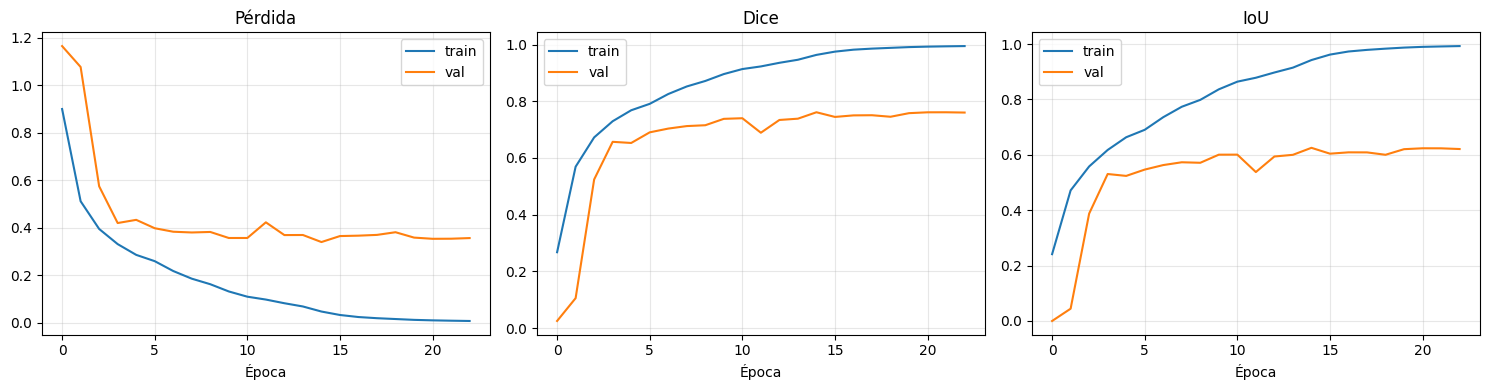

In [19]:
def plot_history(h):
    hist = h.history
    metrics = [("loss", "Pérdida"),
               ("dice_coef", "Dice"),
               ("iou_coef", "IoU")]
    fig, axes = plt.subplots(1, len(metrics), figsize=(15, 4))
    for ax, (key, title) in zip(axes, metrics):
        if key in hist:
            ax.plot(hist[key], label="train")
        if "val_" + key in hist:
            ax.plot(hist["val_" + key], label="val")
        ax.set_title(title)
        ax.set_xlabel("Época")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history_final)


## 6. Visualización de predicciones

Esta es la parte clave para la presentación. Para cada ejemplo mostramos 4 paneles:
1. **Entrada**: obstáculos + inicio (verde) + meta (rojo)
2. **Trayectoria real** (A*)
3. **Predicción cruda** (probabilidades del modelo, 0–1)
4. **Predicción binarizada** (umbral 0.5) superpuesta al mapa


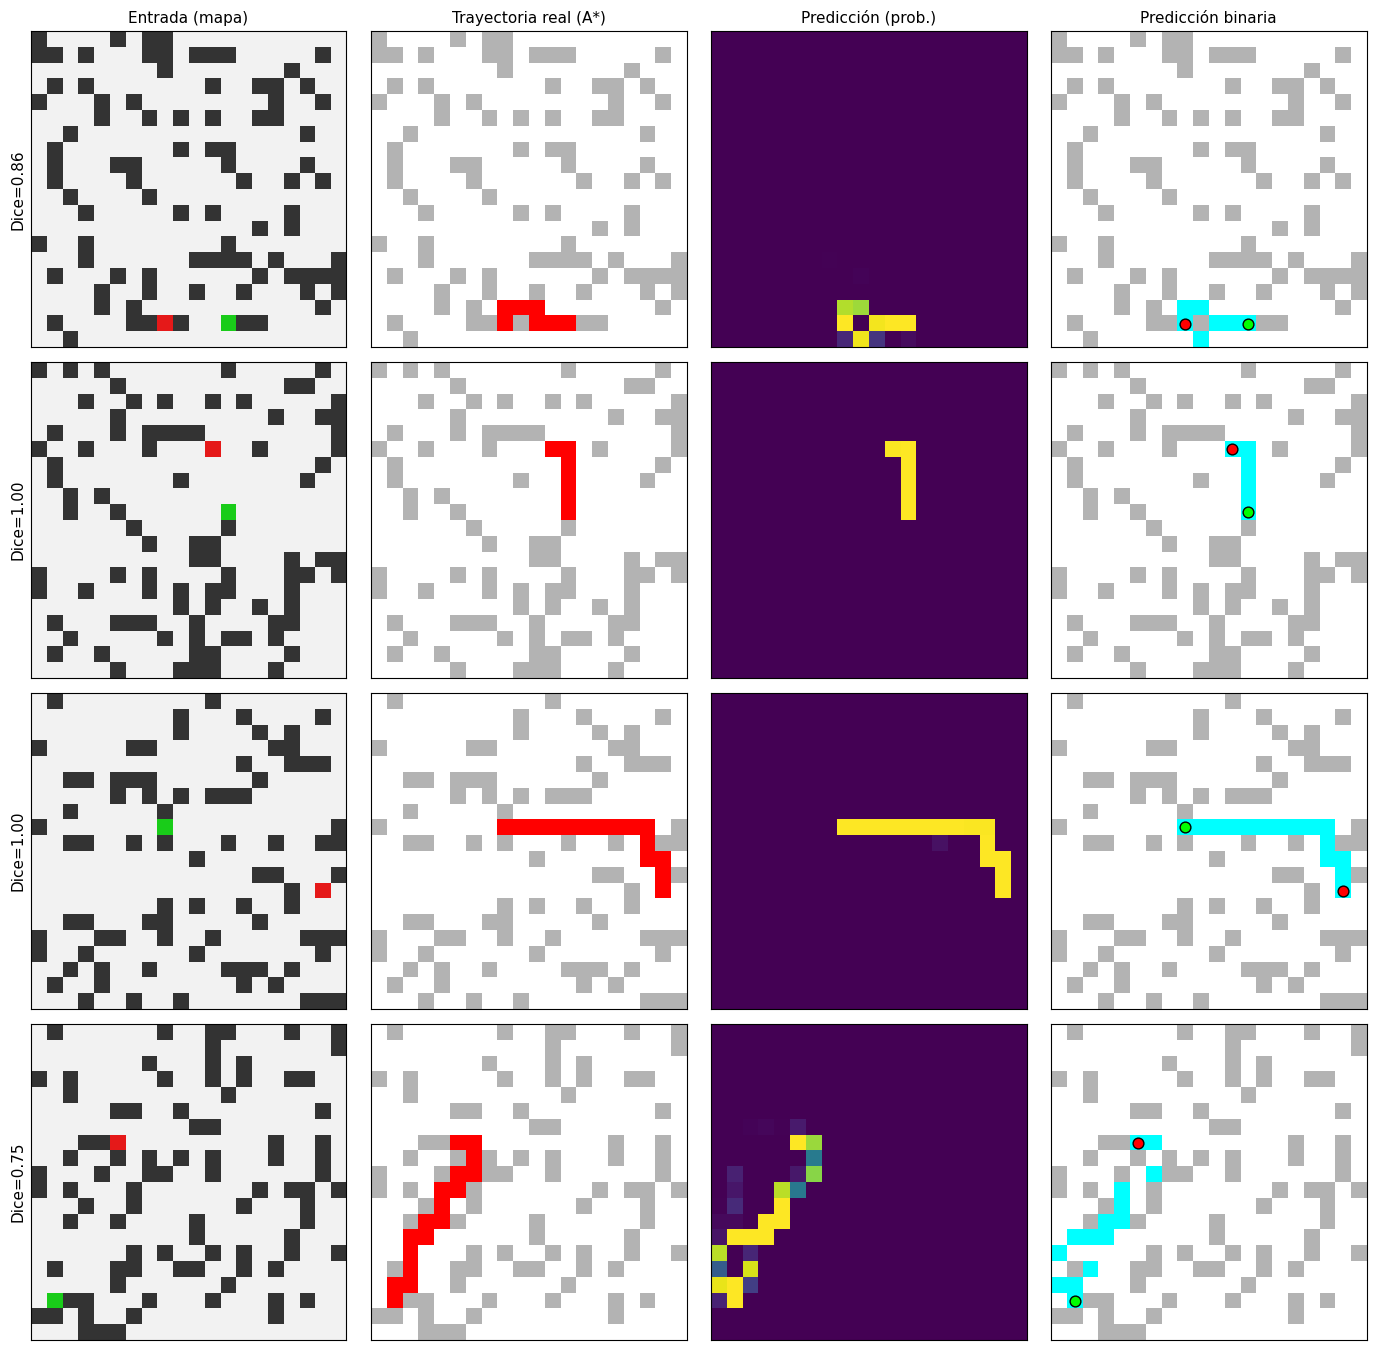

In [20]:
def visualizar_predicciones(model, X, Y, n=4, thr=0.5, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(X), size=n, replace=False)

    preds = model.predict(X[idxs], verbose=0)

    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    if n == 1:
        axes = axes[None, :]

    col_titles = ["Entrada (mapa)", "Trayectoria real (A*)",
                  "Predicción (prob.)", "Predicción binaria"]

    for row, idx in enumerate(idxs):
        obst  = X[idx, :, :, 0]
        start = X[idx, :, :, 1]
        goal  = X[idx, :, :, 2]
        real  = Y[idx, :, :, 0]
        prob  = preds[row, :, :, 0]
        binm  = (prob > thr).astype(np.float32)

        # Panel 1: mapa de entrada
        base = np.zeros((*obst.shape, 3))
        base[obst > 0.5] = [0.2, 0.2, 0.2]      # obstáculos gris
        base[obst <= 0.5] = [0.95, 0.95, 0.95]  # libre claro
        base[start > 0.5] = [0.1, 0.8, 0.1]     # inicio verde
        base[goal  > 0.5] = [0.9, 0.1, 0.1]     # meta rojo
        axes[row, 0].imshow(base)

        # Panel 2: trayectoria real
        axes[row, 1].imshow(obst, cmap="gray_r", alpha=0.3)
        axes[row, 1].imshow(np.ma.masked_where(real < 0.5, real),
                            cmap="autumn")

        # Panel 3: probabilidad cruda
        im = axes[row, 2].imshow(prob, cmap="viridis", vmin=0, vmax=1)

        # Panel 4: predicción binaria sobre el mapa
        axes[row, 3].imshow(obst, cmap="gray_r", alpha=0.3)
        axes[row, 3].imshow(np.ma.masked_where(binm < 0.5, binm),
                            cmap="cool")
        # marcar inicio/meta
        for ch, color in [(start, "lime"), (goal, "red")]:
            ys, xs = np.where(ch > 0.5)
            axes[row, 3].scatter(xs, ys, c=color, s=60,
                                 edgecolors="k", zorder=5)

        for col in range(4):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            if row == 0:
                axes[row, col].set_title(col_titles[col], fontsize=11)

        # Dice de este ejemplo concreto
        d = (2 * (real * binm).sum()) / (real.sum() + binm.sum() + 1e-6)
        axes[row, 0].set_ylabel(f"Dice={d:.2f}", fontsize=11)

    plt.tight_layout()
    plt.show()

visualizar_predicciones(final_model, X_test, Y_test, n=4, seed=42)


### 6.1  Conectividad de la trayectoria predicha
El Dice mide solapamiento de píxeles, pero no si la ruta **conecta** inicio y meta sin cortes. Esta función auxiliar reporta qué fracción de predicciones forman un camino conectado entre los dos puntos

In [21]:
from collections import deque

def camino_conectado(binmask, start_rc, goal_rc):
    """¿Existe un camino de 1s (4-conexo) entre start y goal?"""
    H, W = binmask.shape
    if binmask[start_rc] < 0.5 or binmask[goal_rc] < 0.5:
        return False
    seen = np.zeros_like(binmask, dtype=bool)
    q = deque([start_rc]); seen[start_rc] = True
    while q:
        r, c = q.popleft()
        if (r, c) == goal_rc:
            return True
        for dr, dc in [(1,0),(-1,0),(0,1),(0,-1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < H and 0 <= nc < W and not seen[nr, nc] \
               and binmask[nr, nc] > 0.5:
                seen[nr, nc] = True
                q.append((nr, nc))
    return False

def tasa_conectividad(model, X, Y, thr=0.5):
    preds = model.predict(X, verbose=0)[..., 0]
    ok = 0
    for i in range(len(X)):
        start_rc = tuple(np.argwhere(X[i,:,:,1] > 0.5)[0])
        goal_rc  = tuple(np.argwhere(X[i,:,:,2] > 0.5)[0])
        binm = (preds[i] > thr).astype(np.float32)
        # forzamos inicio/meta como parte del camino
        binm[start_rc] = 1; binm[goal_rc] = 1
        ok += camino_conectado(binm, start_rc, goal_rc)
    print(f"Trayectorias conectadas: {ok}/{len(X)} "
          f"({100*ok/len(X):.1f}%)")

tasa_conectividad(final_model, X_test, Y_test)


Trayectorias conectadas: 461/985 (46.8%)


In [22]:
test_results = final_model.evaluate(X_test, Y_test, verbose=0)

print("=" * 40)
print("MÉTRICAS EN TEST")
print("=" * 40)
for nombre, valor in zip(final_model.metrics_names, test_results):
    print(f"  {nombre:20s}: {valor:.4f}")

MÉTRICAS EN TEST
  loss                : 0.3293
  compile_metrics     : 0.9832
